# 주별 누적 재구매확률 예측 (Discrete-Time Survival)

**입력:** `data/processed/pp_train|pp_val|pp_test.parquet` (person-period 포맷)

**모델링 구조**
- 행 단위 타깃 `y` = "해당 주차에 **최초** 재구매했는가" → 이산시간 hazard $h(t\mid x)$
- 누적 재구매확률 $F(t) = 1 - \prod_{s\le t}\bigl(1 - h(s)\bigr)$ → **단조증가 자동 보장**
- 학습/검증은 **이벤트 주차에서 절단된** 위험집합, 예측은 **4주 전체 그리드**

**평가 이원화**
| 층위 | 데이터 | 타깃 | 지표 |
|---|---|---|---|
| 주차(hazard) | 절단본 | `y` | AUC, PR-AUC, LogLoss, Brier |
| 고객(4주 누적) | 전체 그리드 | `event` | AUC, Brier, 보정곡선, 십분위 lift |

> `pp_test`는 `truncate=False`로 저장되어 있으므로 **주차 지표용 절단본을 이 노트북에서 다시 만든다.**

In [1]:
# ============================================================
# 0. 환경 설정
# ============================================================
# 필요시: pip install lightgbm
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('data/processed')
OUT_DIR  = Path('data/model');  OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

N_WEEKS = 4
SEED = 42
rng = np.random.default_rng(SEED)

print('설정 완료')

설정 완료


## 1. 적재 및 무결성 검증 / 실험용 칼럼 선택

저장 단계에서 `Customer ID`가 문자열로 변환되어 있고 `origin`은 `'YYYY-MM'` 문자열이다.
아래 검증을 **전부 통과해야** 다음 단계로 넘어간다.

In [2]:
# ============================================================
# 1. 적재
# ============================================================
def load_pp(name):
    d = pd.read_parquet(DATA_DIR / f'{name}.parquet')
    d['Customer ID'] = d['Customer ID'].astype(str)
    d['origin'] = d['origin'].astype(str)
    return d

pp_train = load_pp('pp_train')
pp_val   = load_pp('pp_val')
pp_test  = load_pp('pp_test')

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'{nm:5s} {d.shape}  origin: {sorted(d["origin"].unique())}')

print('\n칼럼:', list(pp_train.columns))

# ============================================================
# 2. 실험용 피처 선택 (파일은 23개 다 들고 있음 / 여기서 골라 씀)
# ============================================================
BASE = ['Recency', 'Frequency', 'Monetary',
        'sales_lag_1', 
        'sales_lag_2', 'sales_lag_3',
        'orders_lag_1', 'orders_lag_2', 'orders_lag_3',
        'quantity_lag_1', 'customer_tenure',
        'Segment', 'week', 'pred_month']

# 실험 단계별 추가 세트
ADD_1 = ['avg_order_value', 'last_order_value', 'std_order_value']
ADD_2 = ['max_order_value', 'avg_purchase_qty', 'sales_per_tenure']
# sales_30d / 'sales_trend_1m' / 'sales_90d 중복이라 제외
# pred_month exc.
MODEL_FEATS = BASE    # ← 기준선. 1차는 BASE + ADD_1 로 바꿔가며 실험
CAT_FEATS   = ['Segment']     # CatBoost 범주형

# 파일에 실제 있는지 방어
missing = [c for c in MODEL_FEATS if c not in pp_train.columns]
assert not missing, f'파일에 없는 피처: {missing}'

train (260439, 30)  origin: ['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08']
val   (19847, 30)  origin: ['2011-09']
test  (22476, 30)  origin: ['2011-10']

칼럼: ['Customer ID', 'origin', 'split', 'Recency', 'Frequency', 'Monetary', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'orders_lag_1', 'orders_lag_2', 'orders_lag_3', 'quantity_lag_1', 'customer_tenure', 'Segment', 'week', 'pred_month', 'month', 'avg_order_value', 'sales_30d', 'sales_90d', 'last_order_value', 'max_order_value', 'std_order_value', 'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure', 'y', 'event', 'week_of_repurchase']


In [3]:

# ============================================================
# 2. 무결성 검증 (실패 시 즉시 중단)
# ============================================================
EXPECTED_SHAPE = {'train': (260439, 30), 'val': (19847, 30), 'test': (22476, 30)}

KEYS  = ['Customer ID', 'origin', 'split']
FEATS = ['Recency', 'Frequency', 'Monetary',
         'sales_lag_1', 'sales_lag_2', 'sales_lag_3',
         'orders_lag_1', 'orders_lag_2', 'orders_lag_3',
         'quantity_lag_1', 'customer_tenure', 'month',
         # ── 파생 9개 전부 (파일 스키마) ──
         'avg_order_value', 'sales_30d', 'sales_90d',
         'last_order_value', 'max_order_value', 'std_order_value',
         'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure',
         'Segment', 'week', 'pred_month']
LABEL = ['y', 'event', 'week_of_repurchase']

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    assert d.shape == EXPECTED_SHAPE[nm], f'{nm} 형태 불일치: {d.shape}'
    assert set(KEYS + FEATS + LABEL) == set(d.columns), f'{nm} 칼럼 불일치'
    # 키 유일성: (고객, origin, 주차)
    assert not d.duplicated(['Customer ID', 'origin', 'week']).any(), f'{nm} 키 중복'
    # 주차 범위
    assert d['week'].between(1, N_WEEKS).all(), f'{nm} week 범위 이상'
    # y는 고객-origin당 최대 1회
    assert d.groupby(['Customer ID', 'origin'])['y'].sum().max() <= 1, f'{nm} y 중복 발생'
    # 라벨 정합성: y=1인 행은 반드시 event=1 이고 week == week_of_repurchase
    pos = d[d['y'] == 1]
    assert (pos['event'] == 1).all() and (pos['week'] == pos['week_of_repurchase']).all(), f'{nm} 라벨 불일치'

# 누수 컬럼 잔존 확인
LEAK = ['target_next_purchase', 'target_next_sales', 'next_month_orders',
        'last_week', 'monthly_last_purchase', 'last_purchase_date', 'month_end']
assert not (set(LEAK) & set(pp_train.columns)), '누수 컬럼 잔존'
assert not (set(LABEL) & set(FEATS)), '라벨이 피처에 포함됨'

print('무결성 검증 통과')

무결성 검증 통과


In [4]:
declared = set(KEYS + FEATS + LABEL)   # 29개
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    extra = sorted(set(d.columns) - declared)
    print(f'{nm}: {d.shape[1]}열, 여분 → {extra}')

train: 30열, 여분 → []
val: 30열, 여분 → []
test: 30열, 여분 → []


In [5]:
# ============================================================
# 3. 결측 / 분포 점검
# ============================================================
na = pd.DataFrame({
    'train': pp_train[FEATS].isna().mean(),
    'val':   pp_val[FEATS].isna().mean(),
    'test':  pp_test[FEATS].isna().mean(),
}).round(4)
print('결측률 확인(0인 행 생략)')
print(na[(na > 0).any(axis=1)])
# sales_lag_2/3, orders_lag_2/3 은 고객 초기 월에서 NaN → LightGBM이 결측 분기로 자체 처리

print('\n[주의] pred_month 분포 — split별 고유값')
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'  {nm:5s}: {sorted(int(v) for v in d["pred_month"].unique())}')

print('\ntrain 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)')
print(pp_train.groupby('pred_month')['origin'].nunique().to_frame('n_origins').T)

결측률 확인(0인 행 생략)
               train     val    test
sales_lag_2   0.0500  0.0345  0.0390
sales_lag_3   0.1037  0.0537  0.0721
orders_lag_2  0.0500  0.0345  0.0390
orders_lag_3  0.1037  0.0537  0.0721

[주의] pred_month 분포 — split별 고유값
  train: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  val  : [10]
  test : [11]

train 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)
pred_month  1   2   3   4   5   6   7   8   9   10  11  12
n_origins    1   1   1   2   2   2   2   2   2   1   1   1


## 2. 절단본 생성 — 주차 지표 평가용

`pp_test`는 `truncate=False`(4주 전체)로 저장되어 있다.
2주차에 재구매한 고객의 3·4주차 행은 **위험집합에서 이미 이탈**한 관측치이므로,
그대로 두고 hazard 지표를 재면 음성 표본이 인위적으로 늘어 성능이 과대평가된다.

- **주차 hazard 평가** → 절단본 `pp_test_tr`
- **누적확률 산출** → 전체 그리드 `pp_test`

In [6]:
# ============================================================
# 4. 절단 함수
# ============================================================
# 이벤트 주차까지만 남긴다(=위험집합). 학습/검증 저장본과 동일한 규칙.
def truncate_pp(d, n_weeks=N_WEEKS):
    last_week = np.where(d['event'] == 1, d['week_of_repurchase'], n_weeks)
    return d.loc[d['week'] <= last_week].reset_index(drop=True)

# 테스트 데이터를 올바른 위험집합 형태로 절단
pp_test_tr = truncate_pp(pp_test)

# 저장본(train/val)은 이미 절단되어 있는지 역검증
assert len(truncate_pp(pp_train)) == len(pp_train), 'pp_train 절단 상태 불일치'
assert len(truncate_pp(pp_val))   == len(pp_val),   'pp_val 절단 상태 불일치'

print(f'test 전체 그리드 : {len(pp_test):,}행  (hazard {pp_test["y"].mean():.4f}  ← 편향)')
print(f'test 절단본      : {len(pp_test_tr):,}행  (hazard {pp_test_tr["y"].mean():.4f}  ← 올바름)')
print(f'제거된 사후 행   : {len(pp_test) - len(pp_test_tr):,}행')

print('\nsplit별 요약')
summary = pd.DataFrame([
    dict(split='train', rows=len(pp_train), cust=pp_train['Customer ID'].nunique(),
         hazard=pp_train['y'].mean()),
    dict(split='val',   rows=len(pp_val),   cust=pp_val['Customer ID'].nunique(),
         hazard=pp_val['y'].mean()),
    dict(split='test',  rows=len(pp_test_tr), cust=pp_test_tr['Customer ID'].nunique(),
         hazard=pp_test_tr['y'].mean()),
]).round(4)
print(summary)

test 전체 그리드 : 22,476행  (hazard 0.0618  ← 편향)
test 절단본      : 20,112행  (hazard 0.0691  ← 올바름)
제거된 사후 행   : 2,364행

split별 요약
   split    rows  cust  hazard
0  train  260439  5218  0.0551
1    val   19847  5401  0.0530
2   test   20112  5619  0.0691


In [7]:
# ============================================================
# 5. 고객 단위 정답 (4주 내 재구매 여부)
# ============================================================
def customer_truth(d):
    return (d.groupby(['Customer ID', 'origin'], as_index=False)
              .agg(event=('event', 'max'),
                   week_of_repurchase=('week_of_repurchase', 'max')))

truth_test = customer_truth(pp_test)
truth_val  = customer_truth(pp_val)#데이터프레임 변수에 저장

print(f'test 고객수 {len(truth_test):,}  |  4주 내 재구매율 {truth_test["event"].mean():.4f}')
print(f'val  고객수 {len(truth_val):,}  |  4주 내 재구매율 {truth_val["event"].mean():.4f}')

print('\ntest 최초 재구매 주차 분포')
print(truth_test.loc[truth_test['event'] == 1, 'week_of_repurchase']
      .value_counts().sort_index().to_frame('n'))

test 고객수 5,619  |  4주 내 재구매율 0.2474
val  고객수 5,401  |  4주 내 재구매율 0.1948

test 최초 재구매 주차 분포
                      n
week_of_repurchase     
1.0                 400
2.0                 401
3.0                 362
4.0                 227


## 3. 피처 준비(모델에 넣을 입력 데이터(X)와 정답(y)을 만드는 전처리 코드)

- `Segment`, `week`, `pred_month`는 범주형으로 취급 (`week`는 주차별 기저 hazard, `Segment`는 RFM 군집)
- 범주 목록은 **train 기준**으로 고정해 split 간 인코딩 어긋남을 막는다
- 불균형 보정(`is_unbalance`, `scale_pos_weight`, 오버샘플링)은 **쓰지 않는다** — 누적확률의 절대 수준이 곧 산출물이라 보정을 깨면 안 된다

In [8]:
# ============================================================
# 6. 피처 행렬
# ============================================================
CAT = [c for c in ['Segment', 'week', 'pred_month'] if c in MODEL_FEATS]   # ← MODEL_FEATS 기준
NUM = [c for c in MODEL_FEATS if c not in CAT]                             # ← FEATS → MODEL_FEATS

CAT_LEVELS = {c: sorted(pd.unique(pp_train[c].dropna())) for c in CAT}
for c, lv in CAT_LEVELS.items():
    print(f'{c:12s} ({len(lv)}): {[v.item() if hasattr(v, "item") else v for v in lv]}')

def make_X(d, feats=MODEL_FEATS):      # ← FEATS → MODEL_FEATS (핵심)
    X = d[feats].copy()
    for c in CAT:
        if c in X.columns:
            X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    for c in [x for x in feats if x not in CAT]:
        X[c] = X[c].astype('float32')
    return X

# cell 11, make_X 정의 직후 / X_tr 만들기 직전에 삽입
KEY = ['origin', 'Customer ID', 'week']
pp_train = pp_train.sort_values(KEY).reset_index(drop=True)
pp_val   = pp_val.sort_values(KEY).reset_index(drop=True)
pp_test  = pp_test.sort_values(KEY).reset_index(drop=True)

X_tr, y_tr = make_X(pp_train), pp_train['y'].values
X_va, y_va = make_X(pp_val),   pp_val['y'].values
X_te_tr, y_te_tr = make_X(pp_test_tr), pp_test_tr['y'].values
X_te_full = make_X(pp_test)


X_tr, y_tr = make_X(pp_train), pp_train['y'].values
X_va, y_va = make_X(pp_val),   pp_val['y'].values
X_te_tr, y_te_tr = make_X(pp_test_tr), pp_test_tr['y'].values
X_te_full = make_X(pp_test)

for c in CAT:
    n_nan = X_te_full[c].isna().sum() - pp_test[c].isna().sum()
    assert n_nan == 0, f'{c}: test에 미학습 범주 {n_nan}건'

print(f'\nX_tr {X_tr.shape} | X_va {X_va.shape} | X_te(절단) {X_te_tr.shape} | X_te(전체) {X_te_full.shape}')

Segment      (4): ['At Risk', 'Champions', 'Lost', 'New / Promising']
week         (4): [1, 2, 3, 4]
pred_month   (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

X_tr (260439, 14) | X_va (19847, 14) | X_te(절단) (20112, 14) | X_te(전체) (22476, 14)


## 4. 베이스라인

논문 심사에서 "그래서 모델이 뭘 더 했는가"를 방어하려면 **동일한 누적확률 산식**을 쓰는 단순 대조군이 필요하다.

| 이름 | 정의 |
|---|---|
| B0 | 주차별 전체 평균 hazard (개인차 없음) |
| B1 | `Segment × week` 경험 hazard (RFM 군집만 사용) |
| B2 | 로지스틱 회귀 (선형 기저) |

In [9]:
# ============================================================
# 7. B0 / B1 — 경험 hazard 베이스라인 (train 절단본에서 추정)
# ============================================================
h_week = pp_train.groupby('week')['y'].mean()
h_seg  = pp_train.groupby(['Segment', 'week'])['y'].mean()

print('B0: 주차별 평균 hazard')
print(h_week.round(4).to_frame('hazard').T)
print('\nB1: Segment × week hazard')
print(h_seg.unstack().round(4))

# B0: 주차별 평균만 사용
# B1: 세그먼트별·주차별 평균 사용
# 둘 다 복잡한 모델 학습 없이 train 평균을 그대로 활용하는 기준 모델

def predict_b0(d):
    return d['week'].map(h_week).values

def predict_b1(d):
    idx = pd.MultiIndex.from_arrays([d['Segment'], d['week']])
    p = h_seg.reindex(idx).to_numpy()
    fallback = d['week'].map(h_week).to_numpy()      # 미관측 조합은 주차 평균으로
    return np.where(np.isnan(p), fallback, p)


B0: 주차별 평균 hazard
week         1       2       3       4
hazard  0.0594  0.0584  0.0535  0.0478

B1: Segment × week hazard
week                  1       2       3       4
Segment                                        
At Risk          0.0522  0.0562  0.0552  0.0503
Champions        0.1800  0.1750  0.1633  0.1411
Lost             0.0202  0.0211  0.0191  0.0202
New / Promising  0.0533  0.0603  0.0604  0.0584


In [10]:
# ============================================================
# 8. B2 — 로지스틱 회귀
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 금액/빈도는 우편향이 심하므로 log1p 후 표준화 (음수 방어: clip)
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda a: np.log1p(np.clip(a, 0, None)))),
    ('sc',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

logit = Pipeline([
    ('prep', ColumnTransformer([('num', num_pipe, NUM), ('cat', cat_pipe, CAT)])),
    ('clf',  LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
])

logit.fit(pp_train[FEATS].assign(**{c: pp_train[c].astype(str) for c in CAT}), y_tr)

def predict_b2(d):
    return logit.predict_proba(
        d[FEATS].assign(**{c: d[c].astype(str) for c in CAT}))[:, 1]

print('B2 학습 완료 | val hazard 예측 평균:', predict_b2(pp_val).mean().round(4))

B2 학습 완료 | val hazard 예측 평균: 0.0746


## 5. 주모델 — LightGBM hazard

`week`를 피처에 포함시켰으므로 하나의 모델이 주차별 기저 hazard와 개인 효과를 동시에 학습한다.
조기종료 기준은 **LogLoss**(보정 지향), 참고로 AUC도 함께 본다.

In [11]:
# ============================================================
# 9. LightGBM 학습
# ============================================================
import lightgbm as lgb

params = dict(
    objective='binary',
    metric=['binary_logloss', 'auc'],
    learning_rate=0.03, num_leaves=63, min_data_in_leaf=300,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
    lambda_l2=5.0, max_cat_to_onehot=8, verbosity=-1, seed=SEED
)

dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT, free_raw_data=False)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT, reference=dtr, free_raw_data=False)

model = lgb.train(
    params, dtr,
    num_boost_round=3000,
    valid_sets=[dtr, dva],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(150, verbose=True), lgb.log_evaluation(200)],
)

BEST_ITER = model.best_iteration
print(f'\nbest_iteration = {BEST_ITER}')

Training until validation scores don't improve for 150 rounds
[200]	train's binary_logloss: 0.176902	train's auc: 0.800321	val's binary_logloss: 0.185002	val's auc: 0.750567
Early stopping, best iteration is:
[131]	train's binary_logloss: 0.179224	train's auc: 0.792	val's binary_logloss: 0.184713	val's auc: 0.753218

best_iteration = 131


In [12]:
# ============================================================
# 9-b. XGBoost 학습
# ============================================================
import xgboost as xgb

xgb_params = dict(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    enable_categorical=True,     # make_X의 pandas Categorical 그대로 사용
    max_cat_to_onehot=8,
    grow_policy='lossguide',     # LGBM num_leaves=63과 대응
    max_leaves=63,
    max_depth=0,
    learning_rate=0.03,
    min_child_weight=10.0,       # LGBM min_data_in_leaf=300 ≈ 헤시안 300*p(1-p)≈14
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=5.0,
    n_estimators=3000,
    early_stopping_rounds=150,
    random_state=SEED,
    n_jobs=-1,
    # scale_pos_weight 미사용 — 확률 보정 유지
)

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_tr, y_tr,
              eval_set=[(X_tr, y_tr), (X_va, y_va)],   # 조기종료는 마지막(val) 기준
              verbose=200)

XGB_BEST = xgb_model.best_iteration
print(f'\nXGB best_iteration = {XGB_BEST}')

[0]	validation_0-logloss:0.21114	validation_1-logloss:0.20536
[200]	validation_0-logloss:0.17679	validation_1-logloss:0.18526
[302]	validation_0-logloss:0.17407	validation_1-logloss:0.18593

XGB best_iteration = 152


In [13]:
# ============================================================
# 9-c. CatBoost 학습
# ============================================================
from catboost import CatBoostClassifier, Pool

# CatBoost는 pandas Categorical(특히 float 범주)을 거부 → 문자열로 변환
def to_cb(X):
    Z = X.copy()
    for c in CAT:
        if c in Z.columns:
            Z[c] = Z[c].astype(str)
    return Z

CB_TR = Pool(to_cb(X_tr), y_tr, cat_features=CAT)
CB_VA = Pool(to_cb(X_va), y_va, cat_features=CAT)

cat_params = dict(
    loss_function='Logloss',
    eval_metric='Logloss',
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5.0,
    bootstrap_type='Bernoulli',
    subsample=0.85,
    rsm=0.85,
    random_seed=SEED,
    od_type='Iter',
    od_wait=150,
    allow_writing_files=False,
    verbose=200,
    # auto_class_weights 미사용 — 확률 보정 유지
)

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(CB_TR, eval_set=CB_VA, use_best_model=True)

CAT_BEST = cat_model.get_best_iteration()
print(f'\nCatBoost best_iteration = {CAT_BEST}')

0:	learn: 0.6521552	test: 0.6526572	best: 0.6526572 (0)	total: 382ms	remaining: 19m 5s
200:	learn: 0.1844143	test: 0.1886438	best: 0.1880804 (141)	total: 35.1s	remaining: 8m 8s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.1880804425
bestIteration = 141

Shrink model to first 142 iterations.

CatBoost best_iteration = 141


In [14]:
# ============================================================
# 10. hazard 예측
# ============================================================
def predict_lgb(X):
    return model.predict(X, num_iteration=BEST_ITER)

def predict_xgb(X):
    return xgb_model.predict_proba(X, iteration_range=(0, XGB_BEST + 1))[:, 1]

def predict_cat(X):
    return cat_model.predict_proba(Pool(to_cb(X), cat_features=CAT))[:, 1]

pred = {}
for k, d, X in [('val',       pp_val,     X_va),
                ('test_tr',   pp_test_tr, X_te_tr),
                ('test_full', pp_test,    X_te_full)]:
    pred[k] = {
        'B0':   predict_b0(d),
        'B1':   predict_b1(d),
        'B2':   predict_b2(d),
        'LGBM': predict_lgb(X),
        'XGB':  predict_xgb(X),
        'CAT':  predict_cat(X),
    }

print('test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) :',
      pp_test_tr['y'].mean().round(4))
for k, v in pred['test_tr'].items():
    print(f'  {k:5s}: {v.mean():.4f}')

test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) : 0.0691
  B0   : 0.0552
  B1   : 0.0601
  B2   : 0.0765
  LGBM : 0.0652
  XGB  : 0.0668
  CAT  : 0.0725


## 6. 평가 ① — 주차 hazard (절단본)

In [15]:
# ============================================================
# 11. 주차 단위 지표
# ============================================================
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             log_loss, brier_score_loss)

def hazard_metrics(y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return dict(n=len(y), pos=int(y.sum()), base=y.mean(),
                AUC=roc_auc_score(y, p),
                PR_AUC=average_precision_score(y, p),
                LogLoss=log_loss(y, p),
                Brier=brier_score_loss(y, p))

rows = []
for split, yy in [('val', y_va), ('test', y_te_tr)]:
    key = 'val' if split == 'val' else 'test_tr'
    for mdl, p in pred[key].items():
        rows.append(dict(split=split, model=mdl, **hazard_metrics(yy, p)))

hz = pd.DataFrame(rows).set_index(['split', 'model']).round(4)
print(hz)

                 n   pos    base     AUC  PR_AUC  LogLoss   Brier
split model                                                      
val   B0     19847  1052  0.0530  0.5265  0.0566   0.2071  0.0502
      B1     19847  1052  0.0530  0.7095  0.1126   0.1924  0.0486
      B2     19847  1052  0.0530  0.7491  0.1875   0.1889  0.0481
      LGBM   19847  1052  0.0530  0.7532  0.1947   0.1847  0.0468
      XGB    19847  1052  0.0530  0.7529  0.1960   0.1849  0.0469
      CAT    19847  1052  0.0530  0.7500  0.1910   0.1881  0.0473
test  B0     20112  1390  0.0691  0.5269  0.0724   0.2526  0.0645
      B1     20112  1390  0.0691  0.7091  0.1453   0.2326  0.0615
      B2     20112  1390  0.0691  0.7548  0.2403   0.2210  0.0588
      LGBM   20112  1390  0.0691  0.7627  0.2484   0.2186  0.0585
      XGB    20112  1390  0.0691  0.7637  0.2471   0.2183  0.0585
      CAT    20112  1390  0.0691  0.7554  0.2403   0.2212  0.0588


In [16]:
# ============================================================
# 12. 주차별 hazard 보정 확인 (test)
# ============================================================
chk = pp_test_tr[['week', 'y']].copy()
chk['pred'] = pred['test_tr']['LGBM']
tab = chk.groupby('week').agg(n=('y', 'size'), 실제=('y', 'mean'), 예측=('pred', 'mean'))
tab['비율'] = (tab['예측'] / tab['실제']).round(3)
print(tab.round(4))

         n      실제      예측     비율
week                             
1     5619  0.0712  0.0665  0.935
2     5219  0.0768  0.0699  0.909
3     4818  0.0751  0.0633  0.843
4     4456  0.0509  0.0599  1.176


## 7. 평가 ② — 고객 단위 4주 누적확률

$$S(t)=\prod_{s=1}^{t}\bigl(1-\hat h(s)\bigr),\qquad F(t)=1-S(t)$$

생존함수 정의S(t) : t주까지 아직 재구매하지 않을 확률  
주차별 재구매 확률(hazard)을 누적해서, t주 이내 재구매할 확률로 바꾸는 모델  
  
hazard가 $[0,1]$이므로 $F(t)$는 **정의상 단조증가**한다(사후 보정 불필요).

In [17]:
# ============================================================
# 13. 누적확률 산출
# ============================================================
# person-period 전체 그리드 -> 주차별 누적 재구매확률
def cumulative(d, hazard, n_weeks=N_WEEKS):
    out = d[['Customer ID', 'origin', 'week']].copy()
    out['h'] = np.clip(hazard, 1e-9, 1 - 1e-9)
    out = out.sort_values(['Customer ID', 'origin', 'week'])

    # 고객별 4주 전체가 있어야 누적곱이 성립
    cnt = out.groupby(['Customer ID', 'origin'])['week'].size()
    assert (cnt == n_weeks).all(), '전체 그리드가 아님 — truncate=False 데이터를 넣어야 함'

    g = out.groupby(['Customer ID', 'origin'], sort=False)
    out['S'] = g['h'].transform(lambda s: (1 - s).cumprod())
    out['F'] = 1 - out['S']
    return out.reset_index(drop=True)

cum = {m: cumulative(pp_test, p) for m, p in pred['test_full'].items()}

# 단조성 검증
for m, c in cum.items():
    d = c.groupby(['Customer ID', 'origin'])['F'].diff().dropna()
    assert (d >= -1e-12).all(), f'{m}: 누적확률 단조성 위반'
print('단조증가 검증 통과')

cum['LGBM'].head(8).round(4)

단조증가 검증 통과


,Customer ID,origin,week,h,S,F
0,12346,2011-10,1,0.0291,0.9709,0.0291
1,12346,2011-10,2,0.0315,0.9403,0.0597
2,12346,2011-10,3,0.0315,0.9106,0.0894
3,12346,2011-10,4,0.0307,0.8827,0.1173
4,12347,2011-10,1,0.0541,0.9459,0.0541
5,12347,2011-10,2,0.0829,0.8675,0.1325
6,12347,2011-10,3,0.0864,0.7925,0.2075
7,12347,2011-10,4,0.0905,0.7208,0.2792


In [18]:
# ============================================================
# 14. 고객 단위 지표 (4주 누적 vs 실제 event)
# ============================================================
def customer_scores(c, truth, n_weeks=N_WEEKS):
    f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
    m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
    assert m['F'].notna().all(), '누적확률 결측'
    return m

rows, cust = [], {}
for m, c in cum.items():
    s = customer_scores(c, truth_test)
    cust[m] = s
    rows.append(dict(model=m, n=len(s), 실제=s['event'].mean(), 예측=s['F'].mean(),
                     AUC=roc_auc_score(s['event'], s['F']),
                     PR_AUC=average_precision_score(s['event'], s['F']),
                     LogLoss=log_loss(s['event'], np.clip(s['F'], 1e-6, 1 - 1e-6)),
                     Brier=brier_score_loss(s['event'], s['F'])))

cust_tbl = pd.DataFrame(rows).set_index('model').round(4)
print('=== test 고객 단위 (4주 누적) ===')
print(cust_tbl)

=== test 고객 단위 (4주 누적) ===
          n      실제      예측     AUC  PR_AUC  LogLoss   Brier
model                                                       
B0     5619  0.2474  0.2018  0.5000  0.2474   0.5655  0.1883
B1     5619  0.2474  0.2189  0.7248  0.4292   0.4959  0.1613
B2     5619  0.2474  0.2673  0.7765  0.5856   0.4583  0.1473
LGBM   5619  0.2474  0.2404  0.7846  0.5975   0.4500  0.1446
XGB    5619  0.2474  0.2446  0.7856  0.5980   0.4490  0.1444
CAT    5619  0.2474  0.2609  0.7780  0.5906   0.4585  0.1466


고객별 차이를 전혀 구분하지 않고 전체 평균 재구매율만 예측했을 때 발생하는 확률 오차 수준

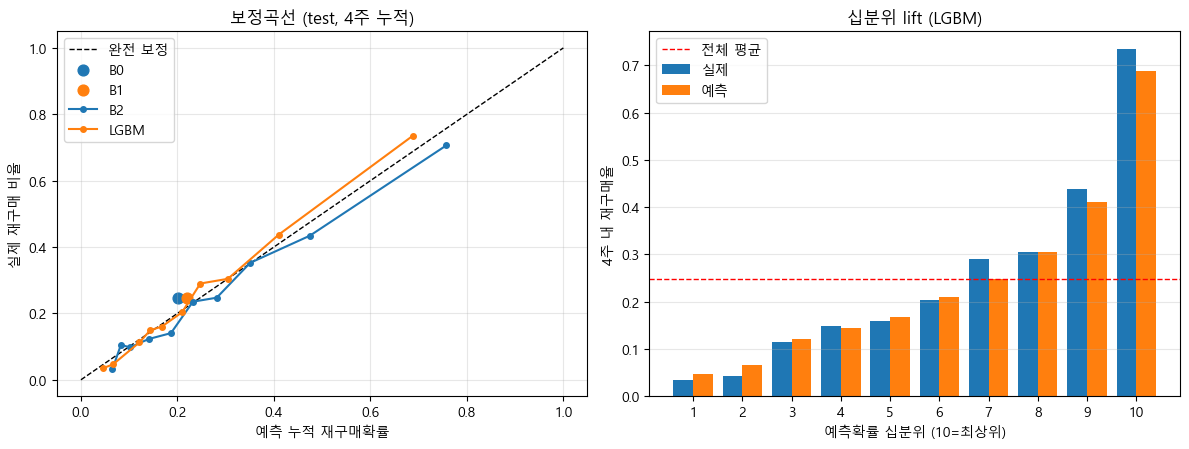

          n      실제      예측
decile                     
1       562  0.0356  0.0466
2       562  0.0427  0.0659
3       562  0.1157  0.1212
4       562  0.1495  0.1437
5       562  0.1601  0.1674
6       561  0.2032  0.2095
7       562  0.2900  0.2475
8       562  0.3043  0.3046
9       562  0.4377  0.4103
10      562  0.7349  0.6875

상위 10% lift: 2.97배


In [19]:
# ============================================================
# 15. 보정곡선 + 십분위 lift
# ============================================================
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='완전 보정')
for m in ['B0', 'B1', 'B2', 'LGBM']:
    s = cust[m]
    if s['F'].nunique() < 5:
        ax.scatter([s['F'].mean()], [s['event'].mean()], s=60, label=m)
        continue
    pt, pp_ = calibration_curve(s['event'], s['F'], n_bins=10, strategy='quantile')
    ax.plot(pp_, pt, 'o-', ms=4, label=m)
ax.set_xlabel('예측 누적 재구매확률'); ax.set_ylabel('실제 재구매 비율')
ax.set_title('보정곡선 (test, 4주 누적)'); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
s = cust['LGBM'].copy()
s['decile'] = pd.qcut(s['F'].rank(method='first'), 10, labels=range(1, 11))
lift = s.groupby('decile').agg(n=('event', 'size'), 실제=('event', 'mean'), 예측=('F', 'mean'))
x = np.arange(1, 11)
ax.bar(x - 0.2, lift['실제'], 0.4, label='실제')
ax.bar(x + 0.2, lift['예측'], 0.4, label='예측')
ax.axhline(s['event'].mean(), color='r', ls='--', lw=1, label='전체 평균')
ax.set_xticks(x); ax.set_xlabel('예측확률 십분위 (10=최상위)'); ax.set_ylabel('4주 내 재구매율')
ax.set_title('십분위 lift (LGBM)'); ax.legend(); ax.grid(alpha=.3, axis='y')

plt.tight_layout(); plt.savefig(FIG_DIR / 'calibration_lift.png', dpi=150); plt.show()

print(lift.round(4))
print(f"\n상위 10% lift: {lift.loc[10,'실제'] / s['event'].mean():.2f}배")

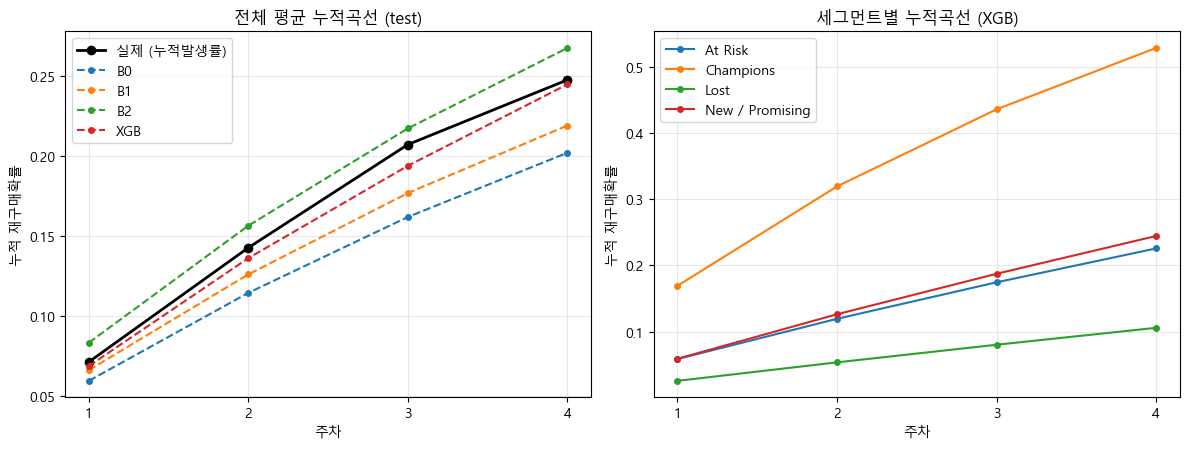

   week      실제     XGB
0     1  0.0712  0.0686
1     2  0.1426  0.1360
2     3  0.2070  0.1937
3     4  0.2474  0.2446


In [20]:
# ============================================================
# 16. 주차별 누적곡선 — 예측 vs 실제 (XGB 기준)
# ============================================================
obs = [((truth_test['event'] == 1) &
        (truth_test['week_of_repurchase'] <= t)).mean() for t in range(1, N_WEEKS + 1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot(range(1, N_WEEKS + 1), obs, 'ko-', lw=2, label='실제 (누적발생률)')
for m in ['B0', 'B1', 'B2', 'XGB']:                         # ← LGBM → XGB
    ax.plot(range(1, N_WEEKS + 1),
            cum[m].groupby('week')['F'].mean().values, 'o--', ms=4, label=m)
ax.set_xticks(range(1, N_WEEKS + 1))
ax.set_xlabel('주차'); ax.set_ylabel('누적 재구매확률')
ax.set_title('전체 평균 누적곡선 (test)'); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
seg_map = pp_test.drop_duplicates(['Customer ID', 'origin'])[['Customer ID', 'origin', 'Segment']]
cs = cum['XGB'].merge(seg_map, on=['Customer ID', 'origin'])   # ← LGBM → XGB
for seg, g in cs.groupby('Segment'):
    ax.plot(range(1, N_WEEKS + 1), g.groupby('week')['F'].mean().values, 'o-', ms=4, label=seg)
ax.set_xticks(range(1, N_WEEKS + 1))
ax.set_xlabel('주차'); ax.set_ylabel('누적 재구매확률')
ax.set_title('세그먼트별 누적곡선 (XGB)'); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.savefig(FIG_DIR / 'cumulative_curves.png', dpi=150); plt.show()

print(pd.DataFrame({'week': range(1, N_WEEKS + 1), '실제': obs,
                    'XGB': cum['XGB'].groupby('week')['F'].mean().values}).round(4))

## 8. 진단

### 8-1. `pred_month` 앰블레이션 (⚠️ 중요)

월말 origin + 28일 창 구조상 `pred_month`는 **origin당 한 값**이다.
따라서 test에서는 항상 `11`로 **분산이 0**이며, 학습 근거는 origin `2010-10` **단 하나**다.

- AUC는 영향을 받지 않는다(상수이므로 순위 불변)
- 그러나 **누적확률의 절대 수준(보정)** 은 이 한 origin에 통째로 의존한다

넣은 모델과 뺀 모델을 모두 학습해 지표를 병기하는 것이 방어 가능한 서술이다.

In [21]:
# ============================================================
# 17. pred_month 앰블레이션
# ============================================================
FEATS_NO_PM = [f for f in FEATS if f != 'pred_month']

dtr2 = lgb.Dataset(make_X(pp_train, FEATS_NO_PM), y_tr,
                   categorical_feature=['Segment', 'week'], free_raw_data=False)
dva2 = lgb.Dataset(make_X(pp_val, FEATS_NO_PM), y_va,
                   categorical_feature=['Segment', 'week'], reference=dtr2, free_raw_data=False)

model_no_pm = lgb.train(params, dtr2, num_boost_round=3000,
                        valid_sets=[dva2], valid_names=['val'],
                        callbacks=[lgb.early_stopping(150, verbose=False),
                                   lgb.log_evaluation(0)])

p_te_tr_no = model_no_pm.predict(make_X(pp_test_tr, FEATS_NO_PM),
                                 num_iteration=model_no_pm.best_iteration)
p_te_fu_no = model_no_pm.predict(make_X(pp_test, FEATS_NO_PM),
                                 num_iteration=model_no_pm.best_iteration)

cum_no = cumulative(pp_test, p_te_fu_no)
s_no = customer_scores(cum_no, truth_test)

abl = pd.DataFrame([
    dict(model='LGBM (+pred_month)',
         주차AUC=roc_auc_score(y_te_tr, pred['test_tr']['LGBM']),
         주차LogLoss=log_loss(y_te_tr, np.clip(pred['test_tr']['LGBM'], 1e-6, 1 - 1e-6)),
         고객AUC=cust_tbl.loc['LGBM', 'AUC'],
         고객Brier=cust_tbl.loc['LGBM', 'Brier'],
         예측평균=cust['LGBM']['F'].mean()),
    dict(model='LGBM (-pred_month)',
         주차AUC=roc_auc_score(y_te_tr, p_te_tr_no),
         주차LogLoss=log_loss(y_te_tr, np.clip(p_te_tr_no, 1e-6, 1 - 1e-6)),
         고객AUC=roc_auc_score(s_no['event'], s_no['F']),
         고객Brier=brier_score_loss(s_no['event'], s_no['F']),
         예측평균=s_no['F'].mean()),
]).set_index('model').round(4)

abl['실제평균'] = truth_test['event'].mean().round(4)
print(abl)
print('\n→ AUC 차이가 미미하고 예측평균만 움직이면, pred_month는 계절 절편으로만 작동한 것.')

                     주차AUC  주차LogLoss   고객AUC  고객Brier    예측평균    실제평균
model                                                                 
LGBM (+pred_month)  0.7627     0.2186  0.7846   0.1446  0.2404  0.2474
LGBM (-pred_month)  0.7594     0.2214  0.7819   0.1478  0.2198  0.2474

→ AUC 차이가 미미하고 예측평균만 움직이면, pred_month는 계절 절편으로만 작동한 것.


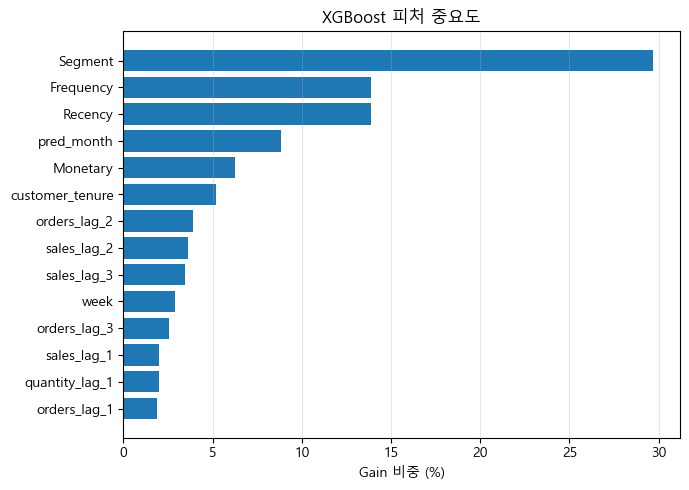

            feature  gain_pct  split
0           Segment     29.71    258
1         Frequency     13.90   1517
2           Recency     13.86   3085
3        pred_month      8.85   2184
4          Monetary      6.26   2724
5   customer_tenure      5.19   1549
6      orders_lag_2      3.87    400
7       sales_lag_2      3.62   1327
8       sales_lag_3      3.43   1461
9              week      2.87   1271
10     orders_lag_3      2.56    415
11      sales_lag_1      2.00   1081
12   quantity_lag_1      2.00   1104
13     orders_lag_1      1.89    410


In [22]:
# ============================================================
# 18. 피처 중요도 (XGB 기준)
# ============================================================
booster = xgb_model.get_booster()

# gain / weight(=split 대응)를 dict로 받아 정렬
gain_d  = booster.get_score(importance_type='total_gain')   # ← gain → total_gain
split_d = booster.get_score(importance_type='weight')

imp = (pd.DataFrame({'feature': xgb_model.feature_names_in_})
       .assign(gain  = lambda d: d['feature'].map(gain_d).fillna(0),
               split = lambda d: d['feature'].map(split_d).fillna(0).astype(int))
       .sort_values('gain', ascending=False).reset_index(drop=True))
imp['gain_pct'] = (imp['gain'] / imp['gain'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'][::-1], imp['gain_pct'][::-1])
ax.set_xlabel('Gain 비중 (%)'); ax.set_title('XGBoost 피처 중요도')
ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.savefig(FIG_DIR / 'feature_importance.png', dpi=150); plt.show()

print(imp[['feature', 'gain_pct', 'split']])

### 8-2. 유의성 검정

LSTM 수요예측에서 쓴 **Diebold-Mariano는 여기 부적합**하다. DM은 시계열 예측오차의 자기상관을 다루는 검정이고,
여기는 고객 단위 이진 분류다. 대신:

- **페어드 부트스트랩** — 고객 단위 재표집으로 $\Delta$Brier / $\Delta$LogLoss 의 신뢰구간
- 필요하면 AUC 차이는 **DeLong 검정**

고객 단위로 재표집해야 한다(주차 행 단위로 하면 같은 고객의 4행이 독립으로 취급되어 CI가 과소추정된다).

## 9. 산출물 저장

In [ ]:
# ablation 셀(30) 맨 위, 또는 cumulative 정의 근처에 추가
def customer_scores(c, truth, n_weeks=N_WEEKS):
    f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
    m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
    assert m['F'].notna().all(), '누적확률 결측'
    return m

In [23]:
# ============================================================
# 20. 저장
# ============================================================
# (A) 고객 × 주차 누적확률
out_weekly = (cum['LGBM']
              .merge(seg_map, on=['Customer ID', 'origin'])
              .merge(truth_test, on=['Customer ID', 'origin'])
              .rename(columns={'h': 'hazard', 'S': 'survival', 'F': 'cum_prob'})
              [['Customer ID', 'origin', 'Segment', 'week',
                'hazard', 'survival', 'cum_prob', 'event', 'week_of_repurchase']])
out_weekly.to_parquet(OUT_DIR / 'repurchase_weekly_prob_test.parquet', index=False)
out_weekly.to_csv(OUT_DIR / 'repurchase_weekly_prob_test.csv',
                  index=False, encoding='utf-8-sig')

# (B) 고객 단위 4주 누적
cust['LGBM'].rename(columns={'F': 'cum_prob_4w'}).to_csv(
    OUT_DIR / 'repurchase_4w_prob_test.csv', index=False, encoding='utf-8-sig')

# (C) 성능 요약 + 모델
hz.to_csv(OUT_DIR / 'metrics_hazard.csv', encoding='utf-8-sig')
cust_tbl.to_csv(OUT_DIR / 'metrics_customer.csv', encoding='utf-8-sig')
abl.to_csv(OUT_DIR / 'metrics_ablation.csv', encoding='utf-8-sig')
model.save_model(str(OUT_DIR / 'lgbm_hazard.txt'), num_iteration=BEST_ITER)

json.dump({'best_iteration': int(BEST_ITER), 'n_weeks': N_WEEKS,
           'feats': FEATS, 'cat': CAT, 'params': {k: str(v) for k, v in params.items()}},
          open(OUT_DIR / 'model_config.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=2)

print('저장 완료 →', OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(' ', p.name)

저장 완료 → C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model
  hypothesis_test_cat.csv
  hypothesis_test_xgb.csv
  lgbm_hazard.txt
  metrics_ablation.csv
  metrics_customer.csv
  metrics_hazard.csv
  metrics_rolling_origin.csv
  model_config.json
  repurchase_4w_prob_test.csv
  repurchase_weekly_prob_test.csv
  repurchase_weekly_prob_test.parquet
  table_hazard_test.csv


In [24]:
# ============================================================
# R0. 전체 그리드 복원 및 pp_all 구성
# ============================================================
def expand_full_grid(d, n_weeks=N_WEEKS):
    keys    = ['Customer ID', 'origin']
    varying = ['week', 'y']
    const   = [c for c in d.columns if c not in keys + varying]

    nun = d.groupby(keys, observed=True)[const].nunique()
    bad = nun.columns[(nun > 1).any()].tolist()
    assert not bad, f'주차별로 값이 변하는 컬럼: {bad}'

    base = d.sort_values(keys + ['week']).drop_duplicates(keys)[keys + const]
    grid = base.merge(pd.DataFrame({'week': np.arange(1, n_weeks + 1)}), how='cross')
    grid['y']    = ((grid['event'] == 1) &
                    (grid['week'] == grid['week_of_repurchase'])).astype(d['y'].dtype)
    grid['week'] = grid['week'].astype(d['week'].dtype)
    return grid[d.columns].sort_values(keys + ['week']).reset_index(drop=True)

pp_all = pd.concat([expand_full_grid(pp_train),
                    expand_full_grid(pp_val),
                    pp_test], ignore_index=True)

# --- dtype 정합: make_X의 CAT_LEVELS(=pp_train 기준)와 값 타입을 맞춘다 ---
#     pred_month가 object('10')로 새면 CAT_LEVELS(int)와 매칭 실패 → 전부 NaN 되는 사고 방지
for c in CAT:                                   # ['Segment','week','pred_month']
    pp_all[c] = pp_all[c].astype(pp_train[c].dtype)

assert not pp_all.duplicated(['Customer ID', 'origin', 'week']).any(), '키 중복'
assert (pp_all.groupby(['Customer ID', 'origin'])['week'].size() == N_WEEKS).all(), '그리드 불완전'

print(f'pp_all {pp_all.shape}')
print(sorted(pp_all['origin'].unique()))
print('pred_month dtype:', pp_all['pred_month'].dtype, '| CAT:', CAT)

pp_all (328364, 30)
['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10']
pred_month dtype: int32 | CAT: ['Segment', 'week', 'pred_month']


In [25]:
# ============================================================
# R0-c. (선택) 폴드별 Segment 재적합 — 기본 미적용
# ============================================================
# 메인 파이프라인(cust)은 저장본 Segment를 그대로 쓴다. test 폴드 == section 19 를
# 유지하려면 test 폴드도 같은 Segment여야 하므로 여기서는 '적용하지 않음'.
# fold1~3 세그먼트 누수를 더 엄격히 막고 싶으면 R2에서 폴드별로
# assign_fold_segment(slice, fit_last) 를 호출하도록 바꿀 수 있으나,
# 그 경우 test 폴드 Segment도 재적합돼 cust와 미세하게 달라질 수 있다(트레이드오프).
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

N_CLUSTERS, RANDOM_STATE, EPSILON = 4, 42, 1e-8
SEGF = ['Recency', 'Frequency', 'Monetary']

panel_rfm = pd.read_parquet(DATA_DIR / 'panel_rfm.parquet')
panel_rfm['Customer ID'] = panel_rfm['Customer ID'].astype(str)
panel_rfm['YearMonth'] = pd.PeriodIndex(panel_rfm['YearMonth'].astype(str), freq='M')  # ← 추가

def _derive_names(prof):
    names, rest = {}, list(prof.index)
    c = prof.loc[rest, 'Monetary'].idxmax(); names[c] = 'Champions';       rest.remove(c)
    c = prof.loc[rest, 'Recency'].idxmax();  names[c] = 'Lost';            rest.remove(c)
    c = prof.loc[rest, 'Recency'].idxmax();  names[c] = 'At Risk';         rest.remove(c)
    names[rest[0]] = 'New / Promising'
    return names

def segment_table(panel_rfm, fit_last, n_clusters=N_CLUSTERS, seed=RANDOM_STATE):
    mask = (panel_rfm[SEGF].notna().all(axis=1)
            & (panel_rfm['Recency'] >= 0)
            & (panel_rfm['Frequency'] > 0)
            & (panel_rfm['Monetary'] > EPSILON))
    fit_mask = mask & (panel_rfm['YearMonth'] <= pd.Period(fit_last, 'M'))

    seg_fit = np.log1p(panel_rfm.loc[fit_mask, SEGF].astype(float))
    seg_all = np.log1p(panel_rfm.loc[mask,     SEGF].astype(float))

    sc = StandardScaler().fit(seg_fit)
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(sc.transform(seg_fit))

    prof  = (panel_rfm.loc[fit_mask, SEGF]
             .assign(_c=km.predict(sc.transform(seg_fit))).groupby('_c')[SEGF].mean())
    names = _derive_names(prof)

    out = panel_rfm[['Customer ID', 'YearMonth']].copy()
    out['Segment'] = pd.Series([names[l] for l in km.predict(sc.transform(seg_all))],
                               index=panel_rfm.index[mask])
    out['origin'] = out['YearMonth'].astype(str)
    return out[['Customer ID', 'origin', 'Segment']]

def assign_fold_segment(pp, fit_last):
    seg = segment_table(panel_rfm, fit_last)
    out = pp.drop(columns='Segment').merge(seg, on=['Customer ID', 'origin'], how='left')
    return out[pp.columns]

print('정의 완료 (기본 미적용 — 저장본 Segment 사용)')

정의 완료 (기본 미적용 — 저장본 Segment 사용)


In [26]:
# ============================================================
# R1. rolling-origin 설계
# ============================================================
FOLDS = [
    dict(name='fold1', train=('2010-03', '2011-06'), eval='2011-07'),
    dict(name='fold2', train=('2010-03', '2011-07'), eval='2011-08'),
    dict(name='fold3', train=('2010-03', '2011-08'), eval='2011-09'),
    dict(name='test',  train=('2010-03', '2011-09'), eval='2011-10'),
]
# 피처/인코딩은 메인(cell 3·11)의 MODEL_FEATS·CAT·NUM 을 그대로 사용한다.
# ※ 기존 주석("pred_month 제외 — 검증 origin이 미학습 범주")은 사실과 다름:
#    pred_month는 month-of-year(1~12)라 ≥12개월 학습창엔 항상 등장 → 미학습 범주 아님(포함 OK).

def slice_origins(d, lo, hi):
    return d[(d['origin'] >= lo) & (d['origin'] <= hi)].reset_index(drop=True)

for f in FOLDS:
    n = slice_origins(pp_all, *f['train'])['origin'].nunique()
    print(f"{f['name']:6s} train origin {f['train'][0]}~{f['train'][1]} ({n}개) → eval {f['eval']}")

fold1  train origin 2010-03~2011-06 (16개) → eval 2011-07
fold2  train origin 2010-03~2011-07 (17개) → eval 2011-08
fold3  train origin 2010-03~2011-08 (18개) → eval 2011-09
test   train origin 2010-03~2011-09 (19개) → eval 2011-10


In [27]:
# ============================================================
# R2. 폴드 단위 학습 · 평가  (메인 파이프라인과 동일 recipe)
# ============================================================
def run_fold(fold, pp_all, n_weeks=N_WEEKS, verbose=False):
    lo, hi, ev = fold['train'][0], fold['train'][1], fold['eval']
    KEY = ['origin', 'Customer ID', 'week']

    pp_all = assign_fold_segment(pp_all, fit_last=hi)   # ← ★ 이 줄 추가 (경계 재적합)
    
    tr_all = truncate_pp(slice_origins(pp_all, lo, hi))
    inner  = sorted(tr_all['origin'].unique())[-1]
    fit    = tr_all[tr_all['origin'] <  inner].sort_values(KEY).reset_index(drop=True)   # ← 정렬
    es     = tr_all[tr_all['origin'] == inner].sort_values(KEY).reset_index(drop=True)   # ← 정렬

    ev_full = pp_all[pp_all['origin'] == ev].sort_values(KEY).reset_index(drop=True)     # ← 정렬
    ev_tr   = truncate_pp(ev_full)

    Xf, yf = make_X(fit),    fit['y'].values
    Xe, ye = make_X(es),     es['y'].values
    Xv, yv = make_X(ev_tr),  ev_tr['y'].values
    Xg     = make_X(ev_full)
    # ... 이하 B0/B1/B2/LGBM/XGB/CAT 은 전역 params·xgb_params·cat_params·make_X·to_cb 그대로 ...

    # --- B0 / B1 : 폴드 학습 구간(fit)에서 재추정 ---
    hw = fit.groupby('week')['y'].mean()
    hs = fit.groupby(['Segment', 'week'])['y'].mean()
    def p_b0(d):
        return d['week'].map(hw).values
    def p_b1(d):
        idx = pd.MultiIndex.from_arrays([d['Segment'], d['week']])
        p  = hs.reindex(idx).to_numpy()
        fb = d['week'].map(hw).to_numpy()
        return np.where(np.isnan(p), fb, p)

    # --- B2 : 메인 cell 14와 동일 구조 (NUM/CAT = MODEL_FEATS 기준) ---
    num_p = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('log', FunctionTransformer(lambda a: np.log1p(np.clip(a, 0, None)))),
                      ('sc',  StandardScaler())])
    cat_p = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    lgt = Pipeline([('prep', ColumnTransformer([('num', num_p, NUM), ('cat', cat_p, CAT)])),
                    ('clf',  LogisticRegression(max_iter=2000, C=1.0, random_state=SEED))])
    lgt.fit(fit[MODEL_FEATS].assign(**{c: fit[c].astype(str) for c in CAT}), yf)
    def p_b2(d):
        return lgt.predict_proba(d[MODEL_FEATS].assign(**{c: d[c].astype(str) for c in CAT}))[:, 1]

    # --- LGBM : 메인 cell 16과 동일 (params/valid_sets/metric 재사용) ---
    dtr = lgb.Dataset(Xf, yf, categorical_feature=CAT, free_raw_data=False)
    dva = lgb.Dataset(Xe, ye, categorical_feature=CAT, reference=dtr, free_raw_data=False)
    lm = lgb.train(dict(params), dtr, num_boost_round=3000,
                   valid_sets=[dtr, dva], valid_names=['train', 'val'],
                   callbacks=[lgb.early_stopping(150, verbose=verbose), lgb.log_evaluation(0)])
    LB = lm.best_iteration

    # --- XGB : 메인 cell 17과 동일 (xgb_params 재사용) ---
    xm = xgb.XGBClassifier(**xgb_params)
    xm.fit(Xf, yf, eval_set=[(Xf, yf), (Xe, ye)], verbose=False)   # 조기종료는 마지막(val=es) 기준
    XB = xm.best_iteration

    # --- CatBoost : 메인 cell 18과 동일 (cat_params·to_cb 재사용) ---
    cm = CatBoostClassifier(**{**cat_params, 'verbose': False})
    cm.fit(Pool(to_cb(Xf), yf, cat_features=CAT),
           eval_set=Pool(to_cb(Xe), ye, cat_features=CAT), use_best_model=True)

    def P(d, X):
        return {'B0': p_b0(d), 'B1': p_b1(d), 'B2': p_b2(d),
                'LGBM': lm.predict(X, num_iteration=LB),
                'XGB':  xm.predict_proba(X, iteration_range=(0, XB + 1))[:, 1],
                'CAT':  cm.predict_proba(Pool(to_cb(X), cat_features=CAT))[:, 1]}
    p_tr, p_full = P(ev_tr, Xv), P(ev_full, Xg)

    truth = customer_truth(ev_full)
    rows, cust_f = [], {}
    for m in p_tr:
        pv = np.clip(p_tr[m], 1e-6, 1 - 1e-6)
        c  = cumulative(ev_full, p_full[m], n_weeks)
        f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
        s  = truth.merge(f4, on=['Customer ID', 'origin'], validate='one_to_one')
        cust_f[m] = s
        rows.append(dict(
            fold=fold['name'], eval_origin=ev, model=m, n=len(s),
            hz_AUC=roc_auc_score(yv, pv),
            hz_LogLoss=log_loss(yv, pv),
            hz_Brier=brier_score_loss(yv, pv),
            cu_AUC=roc_auc_score(s['event'], s['F']),
            cu_PR=average_precision_score(s['event'], s['F']),
            cu_LogLoss=log_loss(s['event'], np.clip(s['F'], 1e-6, 1 - 1e-6)),
            cu_Brier=brier_score_loss(s['event'], s['F']),
            실제=s['event'].mean(), 예측=s['F'].mean()))
    return pd.DataFrame(rows), cust_f

1. run_fold를 메인과 동일 recipe로 통일(피처 14열·pred_month 범주형·early-stop 동일) 
2. 행 순서 정렬로 서브샘플까지 맞춤

In [28]:
# (a) 각 폴드 경계가 eval보다 과거인가 → 전부 True 여야 클린
for f in FOLDS:
    ok = f['train'][1] < f['eval']
    print(f"{f['name']:6s} seg_fit_last={f['train'][1]} < eval {f['eval']}  →  {ok}")

# (b) fit_last=2011-08 재적합이 저장본 Segment를 재현하는가 (머신·라벨 검증)
ref08 = segment_table(panel_rfm, '2011-08')
saved = pp_all[['Customer ID', 'origin', 'Segment']].dropna().drop_duplicates()
m = saved.merge(ref08, on=['Customer ID', 'origin'], suffixes=('_saved', '_refit'))
print(f"\n2011-08 재적합 == 저장본 일치율: {(m['Segment_saved']==m['Segment_refit']).mean():.4f} (n={len(m):,})")

fold1  seg_fit_last=2011-06 < eval 2011-07  →  True
fold2  seg_fit_last=2011-07 < eval 2011-08  →  True
fold3  seg_fit_last=2011-08 < eval 2011-09  →  True
test   seg_fit_last=2011-09 < eval 2011-10  →  True

2011-08 재적합 == 저장본 일치율: 1.0000 (n=82,091)


In [29]:
# ============================================================
# R3. 전 폴드 실행 및 집계
# ============================================================
res_list, cust_by_fold = [], {}
for f in FOLDS:
    print(f"\n=== {f['name']} (eval {f['eval']}) ===")
    r, cf = run_fold(f, pp_all, verbose=False)
    res_list.append(r); cust_by_fold[f['name']] = cf
    print(r.set_index('model')[['hz_AUC', 'cu_AUC', 'cu_Brier']].round(4))

res = pd.concat(res_list, ignore_index=True)

cv = res[res['fold'] != 'test']
agg = (cv.groupby('model')[['hz_AUC', 'hz_LogLoss', 'cu_AUC', 'cu_LogLoss', 'cu_Brier']]
         .agg(['mean', 'std']).round(4))
print('\n=== rolling-origin 3-fold 평균±표준편차 (2011-07/08/09) ===')
print(agg)

print('\n=== 최종 test (2011-10) ===')
print(res[res['fold'] == 'test'].set_index('model')
        [['hz_AUC', 'hz_LogLoss', 'cu_AUC', 'cu_LogLoss', 'cu_Brier', '실제', '예측']].round(4))


=== fold1 (eval 2011-07) ===
       hz_AUC  cu_AUC  cu_Brier
model                          
B0     0.4982  0.5000    0.1347
B1     0.7670  0.7754    0.1112
B2     0.8111  0.8304    0.0997
LGBM   0.8154  0.8344    0.1003
XGB    0.8157  0.8343    0.0991
CAT    0.8187  0.8369    0.0982

=== fold2 (eval 2011-08) ===
       hz_AUC  cu_AUC  cu_Brier
model                          
B0     0.5010  0.5000    0.1544
B1     0.7254  0.7496    0.1315
B2     0.7778  0.7968    0.1206
LGBM   0.7855  0.8026    0.1189
XGB    0.7849  0.8019    0.1194
CAT    0.7839  0.8023    0.1255

=== fold3 (eval 2011-09) ===
       hz_AUC  cu_AUC  cu_Brier
model                          
B0     0.5265  0.5000    0.1569
B1     0.7095  0.7238    0.1402
B2     0.7490  0.7660    0.1354
LGBM   0.7521  0.7690    0.1299
XGB    0.7502  0.7680    0.1302
CAT    0.7492  0.7662    0.1323

=== test (eval 2011-10) ===
       hz_AUC  cu_AUC  cu_Brier
model                          
B0     0.5269  0.5000    0.1883
B1     0.7094  0.

In [34]:
# ============================================================
# R4. 본문 지표 = rolling test 단일 소스 (hz/cust/cust_tbl 재정의)
# ============================================================
te = res[res['fold'] == 'test'].set_index('model')

hz       = te[['hz_AUC', 'hz_LogLoss', 'hz_Brier']].round(4)          # 주차
cust     = cust_by_fold['test']                                       # 고객 dict {model:[...,event,F]}
cust_tbl = (te[['cu_AUC', 'cu_PR', 'cu_LogLoss', 'cu_Brier', '실제', '예측']]
            .rename(columns={'cu_AUC':'AUC','cu_PR':'PR_AUC',
                             'cu_LogLoss':'LogLoss','cu_Brier':'Brier'}).round(4))

print('=== 주차 (test, rolling) ==='); print(hz)
print('\n=== 고객 4주 (test, rolling) ==='); print(cust_tbl)

=== 주차 (test, rolling) ===
       hz_AUC  hz_LogLoss  hz_Brier
model                              
B0     0.5269      0.2526    0.0645
B1     0.7094      0.2325    0.0615
B2     0.7547      0.2210    0.0588
LGBM   0.7599      0.2222    0.0591
XGB    0.7630      0.2185    0.0585
CAT    0.7553      0.2209    0.0587

=== 고객 4주 (test, rolling) ===
          AUC  PR_AUC  LogLoss   Brier      실제      예측
model                                                 
B0     0.5000  0.2474   0.5655  0.1883  0.2474  0.2018
B1     0.7252  0.4304   0.4956  0.1611  0.2474  0.2194
B2     0.7763  0.5856   0.4584  0.1474  0.2474  0.2674
LGBM   0.7823  0.5963   0.4616  0.1478  0.2474  0.2370
XGB    0.7852  0.5996   0.4499  0.1444  0.2474  0.2433
CAT    0.7778  0.5919   0.4571  0.1462  0.2474  0.2601


In [36]:
# ============================================================
# 17. pred_month 앰블레이션 (rolling test 기준, XGB 대신 LGBM 유지 예시)
# ============================================================
# test 폴드 재현: fit=2010-03~2011-08, es=2011-09, eval=2011-10
_tr = truncate_pp(slice_origins(pp_all, '2010-03', '2011-09'))
_fit = _tr[_tr['origin'] < '2011-09']
_es  = _tr[_tr['origin'] == '2011-09']
_ev  = pp_all[pp_all['origin'] == '2011-10']
KEY = ['origin','Customer ID','week']
_fit, _es, _ev = [d.sort_values(KEY).reset_index(drop=True) for d in (_fit,_es,_ev)]

FEATS_NO_PM = [f for f in MODEL_FEATS if f != 'pred_month']    # ← FEATS → MODEL_FEATS
CAT_NO_PM   = [c for c in CAT if c != 'pred_month']

def _mkX(d, feats, cats):
    X = d[feats].copy()
    for c in cats: X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    for c in [f for f in feats if f not in cats]: X[c] = X[c].astype('float32')
    return X

dtr2 = lgb.Dataset(_mkX(_fit, FEATS_NO_PM, CAT_NO_PM), _fit['y'].values,
                   categorical_feature=CAT_NO_PM, free_raw_data=False)
dva2 = lgb.Dataset(_mkX(_es, FEATS_NO_PM, CAT_NO_PM), _es['y'].values,
                   categorical_feature=CAT_NO_PM, reference=dtr2, free_raw_data=False)
m_no = lgb.train(dict(params), dtr2, num_boost_round=3000,
                 valid_sets=[dva2], callbacks=[lgb.early_stopping(150, verbose=False),
                                               lgb.log_evaluation(0)])

_ev_tr = truncate_pp(_ev)
p_no_tr = m_no.predict(_mkX(_ev_tr, FEATS_NO_PM, CAT_NO_PM), num_iteration=m_no.best_iteration)
p_no_fu = m_no.predict(_mkX(_ev,    FEATS_NO_PM, CAT_NO_PM), num_iteration=m_no.best_iteration)
s_no = customer_scores(cumulative(_ev, p_no_fu), customer_truth(_ev))
# +pred_month 는 rolling test XGB 값 그대로
te = res[res['fold']=='test'].set_index('model')

# -pred_month : XGB 재학습
xm_no = xgb.XGBClassifier(**xgb_params)
xm_no.fit(_mkX(_fit, FEATS_NO_PM, CAT_NO_PM), _fit['y'].values,
          eval_set=[(_mkX(_fit, FEATS_NO_PM, CAT_NO_PM), _fit['y'].values),
                    (_mkX(_es, FEATS_NO_PM, CAT_NO_PM), _es['y'].values)], verbose=False)
XB_no = xm_no.best_iteration

p_no_tr = xm_no.predict_proba(_mkX(_ev_tr, FEATS_NO_PM, CAT_NO_PM),
                              iteration_range=(0, XB_no+1))[:, 1]
p_no_fu = xm_no.predict_proba(_mkX(_ev, FEATS_NO_PM, CAT_NO_PM),
                              iteration_range=(0, XB_no+1))[:, 1]
s_no = customer_scores(cumulative(_ev, p_no_fu), customer_truth(_ev))

abl = pd.DataFrame([
    dict(model='XGB (+pred_month)',
         주차AUC=te.loc['XGB','hz_AUC'], 주차LogLoss=te.loc['XGB','hz_LogLoss'],
         고객AUC=te.loc['XGB','cu_AUC'], 고객Brier=te.loc['XGB','cu_Brier'],
         예측평균=cust['XGB']['F'].mean()),
    dict(model='XGB (-pred_month)',
         주차AUC=roc_auc_score(_ev_tr['y'].values, p_no_tr),
         주차LogLoss=log_loss(_ev_tr['y'].values, np.clip(p_no_tr,1e-6,1-1e-6)),
         고객AUC=roc_auc_score(s_no['event'], s_no['F']),
         고객Brier=brier_score_loss(s_no['event'], s_no['F']),
         예측평균=s_no['F'].mean()),
]).set_index('model').round(4)
abl['실제평균'] = _ev.drop_duplicates(['Customer ID','origin'])['event'].mean().round(4)
print(abl)
# +pred_month 는 rolling test 값 그대로

print('\n→ AUC 차이 미미 + 예측평균만 이동 → pred_month는 계절 절편.')

                    주차AUC  주차LogLoss   고객AUC  고객Brier    예측평균    실제평균
model                                                                
XGB (+pred_month)  0.7630     0.2185  0.7852   0.1444  0.2433  0.2474
XGB (-pred_month)  0.7616     0.2233  0.7842   0.1499  0.1842  0.2474

→ AUC 차이 미미 + 예측평균만 이동 → pred_month는 계절 절편.


In [39]:
# (B) 고객 단위 4주 누적만 저장 (주차별 out_weekly는 그래프 정리 후로 미룸)
cust_by_fold['test']['XGB'].rename(columns={'F':'cum_prob_4w'}).to_csv(
    OUT_DIR / 'repurchase_4w_prob_test.csv', index=False, encoding='utf-8-sig')

# (C) 지표
hz.to_csv(OUT_DIR / 'metrics_hazard.csv', encoding='utf-8-sig')
cust_tbl.to_csv(OUT_DIR / 'metrics_customer.csv', encoding='utf-8-sig')
abl.to_csv(OUT_DIR / 'metrics_ablation.csv', encoding='utf-8-sig')
res.to_csv(OUT_DIR / 'metrics_rolling_origin.csv', index=False, encoding='utf-8-sig')
print('저장 완료 →', OUT_DIR.resolve())

저장 완료 → C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model


In [30]:
# ============================================================
# 19. 단측 페어드 부트스트랩 + Holm 보정 (기준 모델: CatBoost)
#     H0: AUC_CAT ≤ AUC_comp   /   H1: AUC_CAT > AUC_comp
# ============================================================
from sklearn.metrics import roc_auc_score, brier_score_loss

REF   = 'XGB'
COMPS = ['B0', 'B1', 'B2', 'LGBM', 'CAT']

def _aligned(ref, comp):
    src = cust_by_fold['test']                    # ← cust 에서 변경
    a = src[ref ].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    b = src[comp].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    assert (a['Customer ID'].values == b['Customer ID'].values).all(), '고객 정렬 불일치'
    return a['event'].values.astype(float), a['F'].values, b['F'].values

def one_sided_bootstrap(ref, comp, n_boot=2000, seed=SEED):
    """고객 단위 재표집. 동일 인덱스를 두 모델에 적용하는 paired 설계."""
    y, p_ref, p_cmp = _aligned(ref, comp)
    rng, n = np.random.default_rng(seed), len(y)

    d_auc, d_bri = [], []
    for _ in range(n_boot):
        i  = rng.integers(0, n, n)
        yi = y[i]
        if yi.min() == yi.max():          # 한쪽 클래스만 뽑히면 AUC 정의 불가
            continue
        d_auc.append(roc_auc_score(yi, p_ref[i]) - roc_auc_score(yi, p_cmp[i]))
        d_bri.append(np.mean((p_cmp[i] - yi) ** 2) - np.mean((p_ref[i] - yi) ** 2))

    d_auc, d_bri = np.array(d_auc), np.array(d_bri)
    B = len(d_auc)

    # 단측 p = 재표집에서 개선이 나타나지 않은 비율 (+1 보정으로 p>0 보장)
    p_auc = (np.sum(d_auc <= 0) + 1) / (B + 1)
    p_bri = (np.sum(d_bri <= 0) + 1) / (B + 1)

    auc_ref, auc_cmp = roc_auc_score(y, p_ref), roc_auc_score(y, p_cmp)
    bri_ref, bri_cmp = brier_score_loss(y, p_ref), brier_score_loss(y, p_cmp)

    return dict(대조군=comp,
                AUC_대조=auc_cmp, AUC_XGB=auc_ref, ΔAUC=auc_ref - auc_cmp,
                AUC_CI95=f'[{np.percentile(d_auc, 2.5):.4f}, {np.percentile(d_auc, 97.5):.4f}]',
                Brier_대조=bri_cmp, Brier_XGB=bri_ref, ΔBrier=bri_cmp - bri_ref,
                p_단측=p_auc, p_Brier=p_bri)

def holm(pvals):
    """Holm-Bonferroni 순차 보정 (단조성 강제)"""
    m, order = len(pvals), np.argsort(pvals)
    adj, run = np.empty(m), 0.0
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * pvals[idx])
        adj[idx] = min(run, 1.0)
    return adj

ht = pd.DataFrame([one_sided_bootstrap(REF, c) for c in COMPS])
ht['p_Holm']      = holm(ht['p_단측'].values)
ht['유의(α=.05)'] = np.where(ht['p_Holm'] < 0.05, '○', '×')

print(f'단측 페어드 부트스트랩 2,000회 | 기준 모델 {REF} | test origin 고객 {len(cust[REF]):,}명')
print('H0: AUC_XGB ≤ AUC_대조  /  H1: AUC_XGB > AUC_대조')
print('ΔAUC > 0, ΔBrier > 0 이면 XGB 우세 (Brier는 낮을수록 좋으므로 부호 반전)')
print()

fmt = {c: '{:.4f}'.format for c in
       ['AUC_대조','AUC_XGB','ΔAUC','Brier_대조','Brier_XGB','ΔBrier']}
fmt.update({c: '{:.5f}'.format for c in ['p_단측','p_Brier','p_Holm']})
print(ht.to_string(index=False, formatters=fmt))

#ht.to_csv(OUT_DIR / 'hypothesis_test_xgb.csv', index=False, encoding='utf-8-sig')

단측 페어드 부트스트랩 2,000회 | 기준 모델 XGB | test origin 고객 5,619명
H0: AUC_XGB ≤ AUC_대조  /  H1: AUC_XGB > AUC_대조
ΔAUC > 0, ΔBrier > 0 이면 XGB 우세 (Brier는 낮을수록 좋으므로 부호 반전)

 대조군 AUC_대조 AUC_XGB   ΔAUC         AUC_CI95 Brier_대조 Brier_XGB ΔBrier    p_단측 p_Brier  p_Holm 유의(α=.05)
  B0 0.5000  0.7852 0.2852 [0.2712, 0.2990]   0.1883    0.1444 0.0438 0.00050 0.00050 0.00250         ○
  B1 0.7252  0.7852 0.0600 [0.0507, 0.0701]   0.1611    0.1444 0.0167 0.00050 0.00050 0.00250         ○
  B2 0.7763  0.7852 0.0089 [0.0029, 0.0153]   0.1474    0.1444 0.0029 0.00350 0.00050 0.00500         ○
LGBM 0.7823  0.7852 0.0029 [0.0009, 0.0047]   0.1478    0.1444 0.0034 0.00250 0.00050 0.00500         ○
 CAT 0.7778  0.7852 0.0073 [0.0031, 0.0119]   0.1462    0.1444 0.0018 0.00100 0.00150 0.00300         ○


In [31]:
for s in [42, 0, 1, 7, 2024]:
    ht_s = pd.DataFrame([one_sided_bootstrap(REF, c, seed=s) for c in ['LGBM']])
    print(f"seed={s}: LGBM ΔAUC={ht_s['ΔAUC'][0]:.4f}, p_단측={ht_s['p_단측'][0]:.4f}")

seed=42: LGBM ΔAUC=0.0029, p_단측=0.0025
seed=0: LGBM ΔAUC=0.0029, p_단측=0.0020
seed=1: LGBM ΔAUC=0.0029, p_단측=0.0030
seed=7: LGBM ΔAUC=0.0029, p_단측=0.0035
seed=2024: LGBM ΔAUC=0.0029, p_단측=0.0025


In [32]:
key = ['Customer ID', 'origin', 'week']
tr_all = truncate_pp(slice_origins(pp_all, '2010-03', '2011-09'))
fit    = tr_all[tr_all['origin'] < sorted(tr_all['origin'].unique())[-1]].reset_index(drop=True)

same_set   = pp_train[key].sort_values(key).reset_index(drop=True).equals(
             fit[key].sort_values(key).reset_index(drop=True))
same_order = pp_train[key].reset_index(drop=True).equals(fit[key].reset_index(drop=True))
print('행 집합 동일:', same_set, '| 행 순서 동일:', same_order)   # True, False 예상

행 집합 동일: True | 행 순서 동일: False


In [33]:
# 저장본 Segment가 전체기간 기준인지, origin별로 다른지 체크
seg_by_origin = pp_all.groupby('origin')['Segment'].apply(
    lambda s: pp_all.loc[s.index, ['Customer ID','Segment']].drop_duplicates().shape[0])
# 같은 고객이 origin마다 Segment 바뀌는지
chk = (pp_all.drop_duplicates(['Customer ID','origin'])
       .pivot_table(index='Customer ID', columns='origin', values='Segment', aggfunc='first'))
# 한 고객의 origin별 Segment가 다 같으면 → 정적(전역) 라벨 의심
print((chk.nunique(axis=1) == 1).mean(), '비율의 고객이 전 origin 동일 Segment')

0.12922147173835763 비율의 고객이 전 origin 동일 Segment
